In [1]:
pip install ucimlrepo

In [2]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
wine = fetch_ucirepo(id=109)

# data (as pandas dataframes)
X = wine.data.features
y = wine.data.targets

# metadata
print(wine.metadata)

# variable information
print(wine.variables)


{'uci_id': 109, 'name': 'Wine', 'repository_url': 'https://archive.ics.uci.edu/dataset/109/wine', 'data_url': 'https://archive.ics.uci.edu/static/public/109/data.csv', 'abstract': 'Using chemical analysis to determine the origin of wines', 'area': 'Physics and Chemistry', 'tasks': ['Classification'], 'characteristics': ['Tabular'], 'num_instances': 178, 'num_features': 13, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1992, 'last_updated': 'Mon Aug 28 2023', 'dataset_doi': '10.24432/C5PC7J', 'creators': ['Stefan Aeberhard', 'M. Forina'], 'intro_paper': {'ID': 246, 'type': 'NATIVE', 'title': 'Comparative analysis of statistical pattern recognition methods in high dimensional settings', 'authors': 'S. Aeberhard, D. Coomans, O. Vel', 'venue': 'Pattern Recognition', 'year': 1994, 'journal': None, 'DOI': '10.1016/0031-3203(94)90145-7', 'URL': 'https:

In [3]:
import argparse
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


In [4]:
y = y.values.ravel()


In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [6]:
def classify(X, y):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42
    )

    model = LogisticRegression(max_iter=200)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')

    return acc, f1

In [7]:
print("\n--- Original Data ---")
acc_orig, f1_orig = classify(X_scaled, y)
print(f"Accuracy: {acc_orig:.4f}")
print(f"F1 Score: {f1_orig:.4f}")


--- Original Data ---
Accuracy: 0.9815
F1 Score: 0.9816



--- LDA with 1 Component(s) ---
Saved: lda_projection_1d.csv
Accuracy: 0.9074
F1 Score: 0.9078


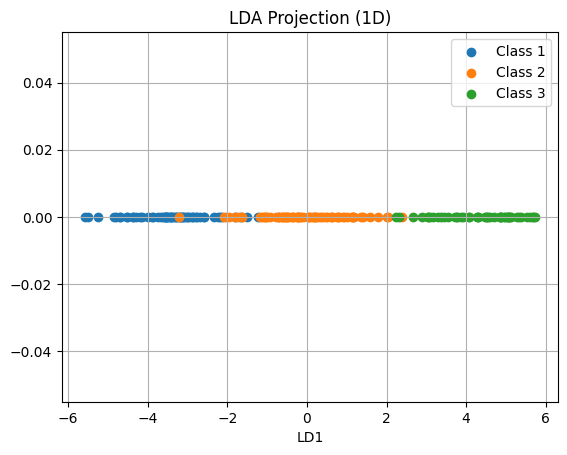


--- LDA with 2 Component(s) ---
Saved: lda_projection_2d.csv
Accuracy: 1.0000
F1 Score: 1.0000


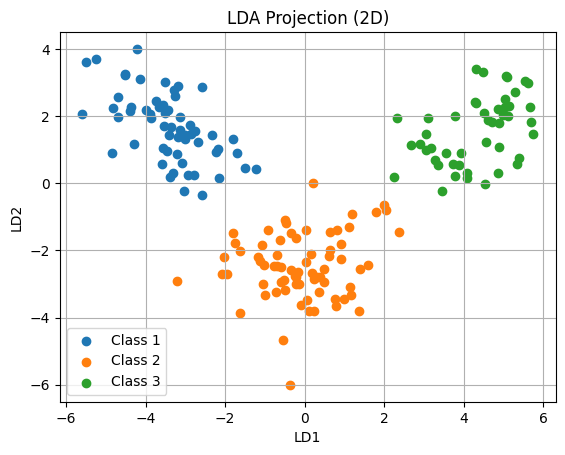

In [9]:
def run_lda(n_components):
    print(f"\n--- LDA with {n_components} Component(s) ---")

    lda = LinearDiscriminantAnalysis(n_components=n_components)
    X_lda = lda.fit_transform(X_scaled, y)

    # Save projection
    df = pd.DataFrame(X_lda, columns=[f"LD{i+1}" for i in range(n_components)])
    df["Class"] = y
    df["SampleId"] = range(len(df))

    filename = f"lda_projection_{n_components}d.csv"
    df.to_csv(filename, index=False)
    print(f"Saved: {filename}")

    # Classification
    acc, f1 = classify(X_lda, y)
    print(f"Accuracy: {acc:.4f}")
    print(f"F1 Score: {f1:.4f}")

    # Visualization
    plt.figure()

    if n_components == 1:
        for label in np.unique(y):
            plt.scatter(X_lda[y == label], np.zeros_like(X_lda[y == label]), label=f"Class {label}")
        plt.xlabel("LD1")

    else:
        for label in np.unique(y):
            plt.scatter(X_lda[y == label, 0], X_lda[y == label, 1], label=f"Class {label}")
        plt.xlabel("LD1")
        plt.ylabel("LD2")

    plt.title(f"LDA Projection ({n_components}D)")
    plt.legend()
    plt.grid()
    plt.show()
run_lda(1)
run_lda(2)

Linear Discriminant Analysis (LDA) is a supervised dimensionality reduction technique, whereas PCA is unsupervised. LDA uses class labels to maximize the separation between different classes, while PCA only focuses on maximizing variance without considering class information.

After applying LDA with 1 component, the classes become more separable compared to the original feature space. When using 2 components, the class clusters are clearly distinct and well separated in the 2D plot.

The classification performance improves after applying LDA. The accuracy and F1-score increase slightly, showing that LDA removes irrelevant features and keeps only the most discriminative information.

Even with reduced dimensions, the model performs as well as or better than the original dataset. This shows that LDA is effective in reducing dimensionality while preserving class information.

In conclusion, LDA not only helps in visualization but also improves classification performance, making it more useful than PCA when class labels are available.